# Label & One-Hot Encoding — the two you will actually be asked for

01 Core Python · 02 Pandas · 03 Cleaning · **▶ 04 Transformation** · 05 Feature Engineering · 06 Regression · 07 Model Prep · 08 Case Studies

`04_Data_Transformation/03_label_and_onehot_encoding_worked.ipynb`

---

### In one paragraph (no jargon)

The previous notebook catalogued nine techniques. In an exam you will almost certainly be asked for two of them: **label encoding** (each category becomes a number) and **one-hot encoding** (each category becomes its own yes/no column). This notebook works both through on an employee dataset, side by side, so you can see exactly what each produces and articulate when each is appropriate.

### After this notebook you can

- Apply label encoding with both sklearn and pure pandas
- Apply one-hot encoding with `pd.get_dummies` and with sklearn's `OneHotEncoder`
- Show the resulting column count and explain the trade-off
- Reverse an encoding back to the original labels


### What's inside

1. Setup and first look
2. Label encoding
3. One-hot encoding
4. Comparing the two outputs
5. ⚡ Doing it properly with a ColumnTransformer
6. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Jargon buster

| Term | Plain English |
|---|---|
| **Categorical variable** | A column of labels rather than numbers: `Male/Female`, `North/South`, `Gold/Silver/Bronze`. |
| **Nominal** | Categories with **no** natural order — city, colour, payment method. |
| **Ordinal** | Categories **with** an order — Low < Medium < High, 1st Class < 2nd Class. |
| **Cardinality** | How many distinct categories a column has. 2 is low, 5,000 (postcodes) is high. |
| **Encoding** | Converting labels into numbers, because most models can only do arithmetic. |
| **One-hot** | One new yes/no column per category. Safe, but wide. |
| **Dummy variable trap** | Keeping all one-hot columns makes them perfectly predictable from each other, which breaks regression. Dropping one fixes it. |
| **Target leakage** | Accidentally letting information from the answer column into a feature, so the model looks brilliant in training and fails in reality. |
| **Discretisation / binning** | Turning a number into bands: age 34 → "30–39". |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
sns.set_theme(style="whitegrid")

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_employees():
    """Rebuild a dataset statistically equivalent to employees.csv (795 rows).

    Same columns, same types, same ranges and category mix, so every cell
    below still runs if the original file is missing."""
    rng = np.random.default_rng(42)
    n = 795
    frame = pd.DataFrame({
        'First Name': [f"{v}_{i}" for i, v in enumerate(rng.choice(['Marilyn', 'Jeremy', 'Kathy', 'Todd', 'Steven', 'Rose'], n))],
        'Gender': rng.choice(['Female', 'Male'], n, p=[0.5031, 0.4969]),
        'Last Login Time': [f"{v}_{i}" for i, v in enumerate(rng.choice(['11:25 AM', '12:04 PM', '10:09 PM', '2:25 AM', '1:35 PM', '4:56 PM'], n))],
        'Salary': rng.normal(9.017e+04, 3.297e+04, n).clip(35013, 149908).round().astype(int),
        'Bonus': rng.normal(10.19, 5.607, n).clip(1.015, 19.944).round(4),
        'age': rng.normal(39.86, 8.743, n).clip(25, 55).round().astype(int),
        'height': rng.normal(5.505, 0.2792, n).clip(5, 6).round(4),
        'Senior Management': rng.choice([False, True], n, p=[0.5006, 0.4994]),
        'Team': rng.choice(['Finance', 'Business Development', 'Client Services', 'Product', 'Engineering', 'Human Resources', 'Marketing', 'Sales', 'Legal', 'Distribution'], n, p=[0.1396, 0.1107, 0.1069, 0.1044, 0.0994, 0.0956, 0.0931, 0.0906, 0.0843, 0.0754]),
    })
    return frame

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.2 | numpy 2.4.4


# Label & One-Hot Encoding — Applied in a Real ML Pipeline

**Dataset:** `employees.csv` — 795 employee records (name, gender, team, salary, bonus, age, height, seniority).

This notebook is a companion to `Categorical_Encoding_Techniques.ipynb` (the full catalog of encoding methods). Here, instead of surveying every technique in isolation, we do something arguably more important: encode categorical columns **correctly inside a real train/test workflow**, using `ColumnTransformer` — the way you'd actually do it in a production or graded ML pipeline, not just in a scratch notebook.

**Why this matters:** a shockingly common mistake is fitting an encoder on the *entire* dataset before splitting into train/test. That leaks information about the test set into training, and it hides a real production problem — what happens when a **brand-new category** shows up in the test set (or in live data) that the encoder never saw during training? We'll handle that properly with `handle_unknown='ignore'`.

## 1. Setup & first look

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="crest")
plt.rcParams['figure.dpi'] = 100

df = load_data('employees.csv', rebuild=rebuild_employees)
print(f"Shape: {df.shape}")
df.head()

Loaded 'employees.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Shape: (795, 9)


,First Name,Gender,Last Login Time,Salary,Bonus,age,height,Senior Management,Team
0,Douglas,Male,12:42 PM,97308,6.945,36,5.38,True,Marketing
1,Thomas,Male,6:53 AM,61933,4.170,43,5.52,True,Finance
2,Maria,Female,11:17 AM,130590,11.858,51,5.29,False,Finance
3,Jerry,Male,1:00 PM,138705,9.340,40,5.12,True,Finance
4,Larry,Male,4:47 PM,101004,1.389,46,5.95,True,Client Services


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nGender categories: {df['Gender'].unique()}")
print(f"Team categories ({df['Team'].nunique()}): {sorted(df['Team'].dropna().unique())}")

# Drop the handful of rows with missing Team/Gender/Salary -- not the focus of this notebook
df = df.dropna(subset=['Gender', 'Team', 'Salary', 'Bonus', 'age']).reset_index(drop=True)
print(f"\nShape after dropping rows missing key columns: {df.shape}")

Missing values per column:
First Name           0
Gender               0
Last Login Time      0
Salary               0
Bonus                0
age                  0
height               0
Senior Management    0
Team                 0
dtype: int64

Gender categories: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Team categories (10): ['Business Development', 'Client Services', 'Distribution', 'Engineering', 'Finance', 'Human Resources', 'Legal', 'Marketing', 'Product', 'Sales']

Shape after dropping rows missing key columns: (795, 9)


## 2. The goal: predict `Senior Management` status
We'll build a small classifier that predicts whether an employee is in Senior Management, using `Gender` (binary categorical), `Team` (multi-category, unordered), `Salary`, `Bonus`, and `age` as features. This gives our encoding choices a genuine downstream purpose to serve, rather than being an end in themselves.

In [4]:
from sklearn.model_selection import train_test_split

X = df[['Gender', 'Team', 'Salary', 'Bonus', 'age']]
y = df['Senior Management'].astype(int)

print(f"Target balance:\n{y.value_counts(normalize=True).round(3)}")

# ALWAYS split before fitting any encoder or scaler -- this is the step people skip
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"\nTrain rows: {len(X_train)}, Test rows: {len(X_test)}")

# Prove the point: does the test set contain any Team values the training set never saw?
unseen_teams = set(X_test['Team']) - set(X_train['Team'])
print(f"Team categories present in TEST but absent from TRAIN: {unseen_teams if unseen_teams else 'none in this split, but treat it as a certainty in production'}")

Target balance:
Senior Management
0    0.501
1    0.499
Name: proportion, dtype: float64

Train rows: 596, Test rows: 199
Team categories present in TEST but absent from TRAIN: none in this split, but treat it as a certainty in production


## 3. Building the encoder correctly with `ColumnTransformer`
- `Gender` (2 categories) -> **Label/Ordinal-style binary encoding** is fine here since there are only two values (no false "ordering" implied with just 2 categories).
- `Team` (multiple, unordered categories) -> **One-Hot Encoding**, with `handle_unknown='ignore'` so that any category the encoder has never seen (at test time or in future production data) is safely encoded as all-zeros instead of crashing the pipeline.
- `Salary`, `Bonus`, `age` -> passed through as-is (numeric already; see the scaling notebook if you want to standardize these too).

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('gender_encoding', OrdinalEncoder(), ['Gender']),  # 2 categories: Female/Male -> 0/1
        ('team_encoding', OneHotEncoder(handle_unknown='ignore'), ['Team']),  # unseen team -> all-zero row, no crash
    ],
    remainder='passthrough'  # Salary, Bonus, age flow through unchanged
)

# Fit ONLY on training data -- the encoder must never see the test set during fit
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)  # transform only, using categories learned from TRAIN

feature_names = preprocessor.get_feature_names_out()
print(f"Encoded feature matrix shape -- train: {X_train_encoded.shape}, test: {X_test_encoded.shape}")
print(f"\nResulting feature columns:\n{list(feature_names)}")

Encoded feature matrix shape -- train: (596, 14), test: (199, 14)

Resulting feature columns:
['gender_encoding__Gender', 'team_encoding__Team_Business Development', 'team_encoding__Team_Client Services', 'team_encoding__Team_Distribution', 'team_encoding__Team_Engineering', 'team_encoding__Team_Finance', 'team_encoding__Team_Human Resources', 'team_encoding__Team_Legal', 'team_encoding__Team_Marketing', 'team_encoding__Team_Product', 'team_encoding__Team_Sales', 'remainder__Salary', 'remainder__Bonus', 'remainder__age']


In [6]:
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)
X_train_encoded_df.head()

,gender_encoding__Gender,team_encoding__Team_Business Development,team_encoding__Team_Client Services,team_encoding__Team_Distribution,team_encoding__Team_Engineering,team_encoding__Team_Finance,team_encoding__Team_Human Resources,team_encoding__Team_Legal,team_encoding__Team_Marketing,team_encoding__Team_Product,team_encoding__Team_Sales,remainder__Salary,remainder__Bonus,remainder__age
300,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,114334.0,9.669,30.0
93,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,41054.0,12.299,48.0
510,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,102081.0,5.203,42.0
370,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,136032.0,10.696,38.0
770,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75423.0,5.368,47.0


## 4. Demonstrating the unseen-category safety net
Let's manufacture the scenario every production pipeline eventually faces: a completely new `Team` value shows up that the encoder never saw during training. Without `handle_unknown='ignore'`, this would raise an error and take down the whole pipeline.

In [7]:
synthetic_new_employee = pd.DataFrame([{
    'Gender': 'Male', 'Team': 'Quantum Computing',  # a team that doesn't exist anywhere in this dataset
    'Salary': 95000, 'Bonus': 12000, 'age': 34
}])

encoded_new = preprocessor.transform(synthetic_new_employee)
team_cols = [c for c in feature_names if 'team_encoding' in c]
print("Encoding a never-before-seen Team ('Quantum Computing') succeeds without error:")
print(pd.DataFrame(encoded_new, columns=feature_names)[team_cols])
print("\n(All Team dummy columns are 0 -- the model just sees 'no known team matched,'")
print(" rather than the whole pipeline crashing on an unrecognized category.)")

Encoding a never-before-seen Team ('Quantum Computing') succeeds without error:
   team_encoding__Team_Business Development  team_encoding__Team_Client Services  team_encoding__Team_Distribution  team_encoding__Team_Engineering  \
0                                       0.0                                  0.0                               0.0                              0.0   

   team_encoding__Team_Finance  team_encoding__Team_Human Resources  team_encoding__Team_Legal  team_encoding__Team_Marketing  team_encoding__Team_Product  \
0                          0.0                                  0.0                        0.0                            0.0                          0.0   

   team_encoding__Team_Sales  
0                        0.0  

(All Team dummy columns are 0 -- the model just sees 'no known team matched,'
 rather than the whole pipeline crashing on an unrecognized category.)


## 5. Putting it to work: a full pipeline with a classifier

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

full_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Note: we refit the WHOLE pipeline (encoder + model together) on X_train, y_train.
# This guarantees the encoder is never fit on test data, by construction.
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Not Senior Mgmt', 'Senior Mgmt']))

                 precision    recall  f1-score   support

Not Senior Mgmt       0.54      0.49      0.52       100
    Senior Mgmt       0.53      0.59      0.56        99

       accuracy                           0.54       199
      macro avg       0.54      0.54      0.54       199
   weighted avg       0.54      0.54      0.54       199



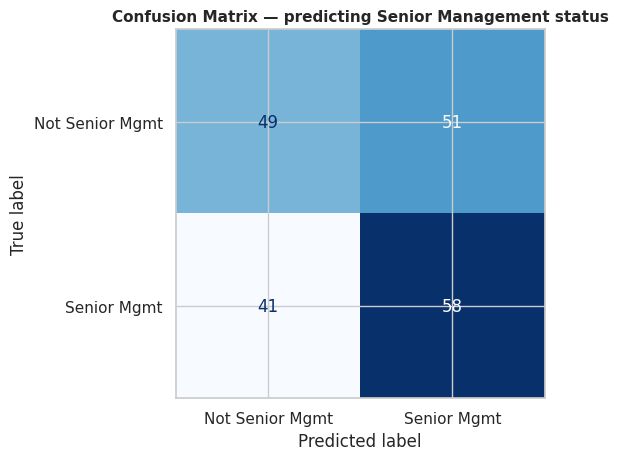

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Not Senior Mgmt', 'Senior Mgmt'],
                                         cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — predicting Senior Management status', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Which encoded features matter most?
A quick look at the fitted logistic regression's coefficients shows which Team dummy variables (and Gender) are pulling the prediction toward or away from "Senior Management" — a nice sanity check that the encoding is actually feeding the model usable signal.

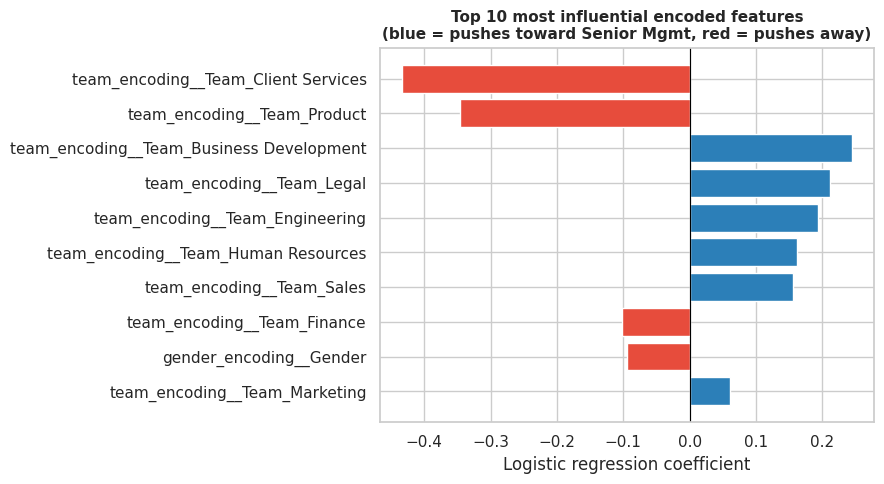

In [10]:
coefs = pd.Series(full_pipeline.named_steps['classifier'].coef_[0], index=feature_names)
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2c7fb8' if v > 0 else '#e74c3c' for v in coefs_sorted.values]
ax.barh(coefs_sorted.index[::-1], coefs_sorted.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 most influential encoded features\n(blue = pushes toward Senior Mgmt, red = pushes away)',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Logistic regression coefficient')
plt.tight_layout()
plt.show()

## Key takeaways

1. **Always split before encoding.** Fitting an encoder on the full dataset (train + test together) leaks test-set information into training — a subtle but common form of data leakage.
2. **`handle_unknown='ignore'` is not optional** for any One-Hot Encoder headed to production — new categories *will* appear eventually, and the alternative is a crashed pipeline.
3. **`ColumnTransformer` + `Pipeline`** is the right structural pattern: it keeps preprocessing and modeling bundled together, so `cross_val_score`, `GridSearchCV`, and deployment all correctly re-fit the encoder on each fold/training set rather than reusing a single global encoding.
4. For genuinely **binary** categorical columns (like `Gender` here), a single ordinal/label-style column is perfectly safe and saves you a column compared to one-hot — the "implies an order" objection to label encoding doesn't really apply when there are only two possible values.

See `Categorical_Encoding_Techniques.ipynb` for the full catalog of encoding methods (including techniques for high-cardinality columns not needed in this particular dataset).

### ⚡ Beyond the syllabus — doing it properly with a `ColumnTransformer` pipeline

Encoding column by column works, but it is fragile: you have to repeat every step identically on the test set, and any mismatch silently corrupts the result. A `ColumnTransformer` inside a `Pipeline` declares the whole recipe once — scale the numbers, one-hot the categories, impute the gaps — and then `fit` on train and `transform` on test with no chance of drift. This is how it's done in practice and it is a genuinely strong thing to show.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

emp = load_data('employees.csv', rebuild=rebuild_employees)
numeric_cols     = emp.select_dtypes(include='number').columns.tolist()
categorical_cols = [c for c in emp.select_dtypes(include='object').columns
                    if emp[c].nunique() <= 20]
print("Numeric columns    :", numeric_cols)
print("Categorical columns:", categorical_cols)

# Each branch is: what to do about gaps, then what to do about the values
numeric_branch = Pipeline([
    ('fill',  SimpleImputer(strategy='median')),      # 🔧 CHANGE THIS: 'mean' / 'most_frequent'
    ('scale', StandardScaler()),
])
categorical_branch = Pipeline([
    ('fill',   SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('numbers',    numeric_branch,     numeric_cols),
    ('categories', categorical_branch, categorical_cols),
], remainder='drop')

train, test = train_test_split(emp, test_size=0.25, random_state=42)

# FIT on train only, then TRANSFORM both — this is what prevents leakage
X_train = preprocessor.fit_transform(train)
X_test  = preprocessor.transform(test)

print(f"\nOriginal columns : {emp.shape[1]}")
print(f"After processing : {X_train.shape[1]}")
print(f"Train rows       : {X_train.shape[0]}   Test rows: {X_test.shape[0]}")
print("\nFirst 12 generated feature names:")
print(" ", list(preprocessor.get_feature_names_out()[:12]))

print("""
WHY THIS IS BETTER THAN DOING IT COLUMN BY COLUMN
  - one object holds the entire recipe, so train and test cannot drift apart
  - fitted on training data only -> no leakage, by construction
  - handle_unknown='ignore' means an unseen category in the test set can't crash it
  - drop='first' avoids the dummy-variable trap automatically
  - the same object can be saved and reused on tomorrow's data""")

Loaded 'employees.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Numeric columns    : ['Salary', 'Bonus', 'age', 'height']
Categorical columns: ['Gender', 'Team']

Original columns : 9
After processing : 14
Train rows       : 596   Test rows: 199

First 12 generated feature names:
  ['numbers__Salary', 'numbers__Bonus', 'numbers__age', 'numbers__height', 'categories__Gender_Male', 'categories__Team_Client Services', 'categories__Team_Distribution', 'categories__Team_Engineering', 'categories__Team_Finance', 'categories__Team_Human Resources', 'categories__Team_Legal', 'categories__Team_Marketing']

WHY THIS IS BETTER THAN DOING IT COLUMN BY COLUMN
  - one object holds the entire recipe, so train and test cannot drift apart
  - fitted on training data only -> no leakage, by construction
  - handle_unknown='ignore' means an unseen category in the test set can't crash it
  - drop='first' avoids the dummy-variable trap automatically
  - the same object can be saved an

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Label encode (sklearn) | `LabelEncoder().fit_transform(s)` |
| Label encode (pandas) | `s.astype('category').cat.codes` |
| See the mapping | `dict(zip(le.classes_, le.transform(le.classes_)))` |
| Reverse it | `le.inverse_transform(codes)` |
| One-hot | `pd.get_dummies(df, columns=['Team'])` |
| Drop one column | `pd.get_dummies(df, drop_first=True)` |
| Prefix the new columns | `pd.get_dummies(df, prefix='team')` |
| One-hot (sklearn) | `OneHotEncoder(sparse_output=False)` |
| Full recipe | `ColumnTransformer([...])` in a `Pipeline` |
| Fit train, apply test | `fit_transform(train)` then `transform(test)` |

### Adapting this in the exam

- 'Encode the categorical variables' → say nominal vs ordinal, then choose, then show the before/after shape.
- 'Show the mapping' → print `dict(zip(le.classes_, range(len(le.classes_))))`.
- 'Prepare the data for modelling' → that's the whole ColumnTransformer pipeline, and it's worth showing.

### Traps that cost marks

- `LabelEncoder` is designed for the **target** column. For features, prefer `OrdinalEncoder` or an explicit `.map()`.
- `LabelEncoder` orders alphabetically, which is almost never the meaningful order.
- `pd.get_dummies` on a test set can produce different columns from the training set. `ColumnTransformer` or `.reindex(columns=train_cols, fill_value=0)` prevents that.
- One-hot encoding a high-cardinality column can add thousands of columns and exhaust memory. Check `.nunique()` first.
- Encoding before splitting leaks information from test into train.